# Fixed Pipeline E2E v12 - RoBERTa News Bias Version with Train/Val/Test Split
All v11 fixes +
  Fix 1: LinearProjectionBlock — two-layer bottleneck with GELU
  Fix 2: compound_state — scalar gate (B,1) instead of per-dim (B,256)
  Fix 3: gate_issue / gate_topic — Linear(512,1)
  Fix 4: ClassifierLayer — hidden layer 2304→512→3
  Fix 5: LR reduced to 3e-4 (stops val oscillation)
  Fix 6: Two-phase training — unfreeze top 4 encoder layers at epoch 10
  Fix 7: Label smoothing 0.15 (helps center class)
  Fix 8: Cosine LR schedule instead of linear decay
  
  *** CHANGED: Using jayanta/roberta-news-bias instead of DeBERTa ***
  *** CHANGED: Train/Val/Test split - 80/10/10 ***

In [54]:
# CELL 0: Imports
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from torch.nn import CrossEntropyLoss
from transformers import RobertaTokenizer, RobertaModel
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from collections import Counter
import logging
from transformers import get_cosine_schedule_with_warmup
import matplotlib.pyplot as plt
import seaborn as sns

logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s | %(levelname)s | %(message)s',
    datefmt='%H:%M:%S'
)
log = logging.getLogger(__name__)

print(f'NumPy  : {np.__version__}')
print(f'Pandas : {pd.__version__}')
print(f'PyTorch: {torch.__version__}')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device : {device}')

NumPy  : 1.26.4
Pandas : 2.1.4
PyTorch: 2.8.0+cu128
Device : cuda


In [55]:
# CELL 1: Load dataset
df = pd.read_csv(r'final_cleaned_dataset.csv')
print(f'Full dataset shape : {df.shape}')
print(f'Columns : {df.columns.tolist()}')
df.head(3)

Full dataset shape : (9166, 8)
Columns : ['News_ID', 'Title', 'News_Body', 'Stance', 'Label', 'issue', 'topic', 'roundup']


,News_ID,Title,News_Body,Stance,Label,issue,topic,roundup
0,0,north carolina house race carries unlikely han...,charlotte no the closely watched special us ho...,lean left,liberal,illegal ballot harvesting prompted re do of no...,voting rights and voter fraud,charlotte no the closely watched special us ho...
1,0,trump unloads on disloyal democratic house can...,high stakes were matched by some of president ...,lean right,conservative,illegal ballot harvesting prompted re do of no...,voting rights and voter fraud,high stakes were matched by some of president ...
2,0,illegal ballot harvesting caused a do over hou...,a us house special election in north carolinas...,center,center,illegal ballot harvesting prompted re do of no...,voting rights and voter fraud,a us house special election in north carolinas...


In [56]:
# CELL 2: Diagnostic - column inspection
print('=' * 60)
print('DIAGNOSTIC: Column inspection')
print('=' * 60)

if 'Label' in df.columns:
    print('\n[Label] unique values:')
    print(df['Label'].value_counts())
else:
    print('WARNING: No column named Label')

if 'issue' in df.columns:
    print(f'\n[issue] null count : {df["issue"].isna().sum()} / {len(df)}')
    print(f'[issue] sample values:')
    print(df['issue'].dropna().head(5).tolist())
else:
    print('WARNING: No column named issue')

if 'topic' in df.columns:
    print(f'\n[topic] null count : {df["topic"].isna().sum()} / {len(df)}')
    print(f'[topic] sample values:')
    print(df['topic'].dropna().head(5).tolist())
else:
    print('WARNING: No column named topic')

for col in ['Title', 'News_Body']:
    if col in df.columns:
        print(f'\n[{col}] null count : {df[col].isna().sum()} / {len(df)}')
    else:
        print(f'WARNING: No column named {col}')

print('\n' + '=' * 60)
print('Read the output above before running any further cells.')
print('=' * 60)

DIAGNOSTIC: Column inspection

[Label] unique values:
Label
liberal         3057
conservative    3055
center          3054
Name: count, dtype: int64

[issue] null count : 0 / 9166
[issue] sample values:
['illegal ballot harvesting prompted re do of north carolinas eth district election', 'illegal ballot harvesting prompted re do of north carolinas eth district election', 'illegal ballot harvesting prompted re do of north carolinas eth district election', 'republican dan bishop wins special election in north carolina', 'republican dan bishop wins special election in north carolina']

[topic] null count : 0 / 9166
[topic] sample values:
['voting rights and voter fraud', 'voting rights and voter fraud', 'voting rights and voter fraud', 'elections', 'elections']

[Title] null count : 0 / 9166

[News_Body] null count : 0 / 9166

Read the output above before running any further cells.


In [57]:
# CELL 3: Train/Val/Test split - 80/10/10
full_df = df.copy()

drop_cols = [c for c in ['News_ID', 'roundup', 'Stance'] if c in full_df.columns]
full_df = full_df.drop(columns=drop_cols)

from sklearn.model_selection import train_test_split

train_df, temp_df = train_test_split(full_df, test_size=0.2, random_state=42, stratify=full_df['Label'])
val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=42, stratify=temp_df['Label'])

print(f'Full dataset     : {full_df.shape}')
print(f'Train (80%)      : {train_df.shape}')
print(f'Val   (10%)      : {val_df.shape}')
print(f'Test  (10%)      : {test_df.shape}')

print(f'\nTrain label distribution:')
print(train_df['Label'].value_counts())
print(f'\nVal label distribution:')
print(val_df['Label'].value_counts())
print(f'\nTest label distribution:')
print(test_df['Label'].value_counts())

Full dataset     : (9166, 5)
Train (80%)      : (7332, 5)
Val   (10%)      : (917, 5)
Test  (10%)      : (917, 5)

Train label distribution:
Label
liberal         2445
conservative    2444
center          2443
Name: count, dtype: int64

Val label distribution:
Label
conservative    306
liberal         306
center          305
Name: count, dtype: int64

Test label distribution:
Label
liberal         306
center          306
conservative    305
Name: count, dtype: int64


In [58]:
# CELL 4: Diagnostic - confirm Label values match LABEL_MAP
print('Label value counts in experiment slice:')
print(test_df['Label'].value_counts())
print()
print('Unique label values:', test_df['Label'].unique().tolist())

Label value counts in experiment slice:
Label
liberal         306
center          306
conservative    305
Name: count, dtype: int64

Unique label values: ['conservative', 'liberal', 'center']


In [59]:
# CELL 5: Constants
ROBERTA_MODEL = 'jayanta/roberta-news-bias'

LABEL_MAP = {'liberal': 0, 'center': 1, 'conservative': 2}
LABEL_NAMES = ['liberal', 'center', 'conservative']

surviving = test_df[test_df['Label'].isin(LABEL_MAP)]
print(f'Rows surviving LABEL_MAP filter : {len(surviving)} / {len(test_df)}')
if len(surviving) == 0:
    print('!!! WARNING: ZERO rows survived the filter !!!')
else:
    print('Label distribution in surviving rows:')
    print(surviving['Label'].value_counts())

DROPOUT = 0.2
max_ctx_len = 64
max_news_len = 192
print(f'\nDROPOUT = {DROPOUT}')

Rows surviving LABEL_MAP filter : 917 / 917
Label distribution in surviving rows:
Label
liberal         306
center          306
conservative    305
Name: count, dtype: int64

DROPOUT = 0.2


In [60]:
# CELL 6: Tokenisers
log.info('Loading tokenisers...')
ctx_tokenizer = RobertaTokenizer.from_pretrained(ROBERTA_MODEL)
news_tokenizer = RobertaTokenizer.from_pretrained(ROBERTA_MODEL)
log.info('Tokenisers ready.')

21:21:17 | INFO | Loading tokenisers...
21:21:17 | INFO | HTTP Request: HEAD https://huggingface.co/jayanta/roberta-news-bias/resolve/main/tokenizer_config.json "HTTP/1.1 307 Temporary Redirect"
21:21:17 | INFO | HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/jayanta/roberta-news-bias/bd1c8f3b4050e275c6d512165d19485982ab1c79/tokenizer_config.json "HTTP/1.1 200 OK"
21:21:17 | INFO | HTTP Request: GET https://huggingface.co/api/models/jayanta/roberta-news-bias/tree/main/additional_chat_templates?recursive=false&expand=false "HTTP/1.1 404 Not Found"
21:21:17 | INFO | HTTP Request: GET https://huggingface.co/api/models/jayanta/roberta-news-bias/tree/main?recursive=true&expand=false "HTTP/1.1 200 OK"
21:21:17 | INFO | HTTP Request: HEAD https://huggingface.co/jayanta/roberta-news-bias/resolve/main/tokenizer_config.json "HTTP/1.1 307 Temporary Redirect"
21:21:17 | INFO | HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/jayanta/roberta-news-bias/bd1c8f3b4

In [61]:
# CELL 7: LinearProjectionBlock
class LinearProjectionBlock(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim, dropout_rate=DROPOUT):
        super().__init__()
        h = hidden_dim[0] if isinstance(hidden_dim, list) else hidden_dim
        self.projection = nn.Sequential(
            nn.Linear(input_dim, h),
            nn.GELU(),
            nn.Dropout(p=dropout_rate),
            nn.Linear(h, output_dim),
            nn.LayerNorm(output_dim, eps=1e-6),
        )

    def forward(self, x):
        return self.projection(x)

print("LinearProjectionBlock defined.")

LinearProjectionBlock defined.


In [62]:
# CELL 8: Encoder (RoBERTa + projection)
class Encoder(nn.Module):
    def __init__(self, model_name, hidden_dim, output_dim,
                 dropout_rate=DROPOUT, freeze_layers=6):
        super().__init__()
        self.roberta = RobertaModel.from_pretrained(model_name)
        for i, layer in enumerate(self.roberta.encoder.layer):
            if i < freeze_layers:
                for p in layer.parameters():
                    p.requires_grad_(False)
        self.projection = LinearProjectionBlock(
            self.roberta.config.hidden_size, hidden_dim, output_dim, dropout_rate)

    def forward(self, input_ids, attention_mask):
        out = self.roberta(input_ids=input_ids, attention_mask=attention_mask)
        pooled = out.pooler_output.float()
        pooled = torch.clamp(pooled, -10.0, 10.0)
        return self.projection(pooled)

print('Encoder defined.')

Encoder defined.


In [63]:
# CELL 9: NewsFeatureExtractor for RoBERTa
class NewsFeatureExtractor(nn.Module):
    def __init__(self, model_name=ROBERTA_MODEL, freeze_layers=6):
        super().__init__()
        self.roberta = RobertaModel.from_pretrained(model_name)
        for i, layer in enumerate(self.roberta.encoder.layer):
            if i < freeze_layers:
                for p in layer.parameters():
                    p.requires_grad_(False)

    def forward(self, input_ids, attention_mask):
        out = self.roberta(input_ids=input_ids, attention_mask=attention_mask)
        last_hidden = out.last_hidden_state
        cls_emb = out.pooler_output
        mask = attention_mask.unsqueeze(-1).expand(last_hidden.size()).float()
        sum_emb = torch.sum(last_hidden * mask, 1)
        sum_mask = torch.clamp(mask.sum(1), min=1e-9)
        mean_emb = sum_emb / sum_mask
        combined = torch.cat([cls_emb, mean_emb], dim=-1)
        return combined

In [64]:
# CELL 10: Text builder
def build_news_text(text: str, max_words: int = 192) -> str:
    return ' '.join(str(text).strip().split()[:max_words])

print('build_news_text defined.')

build_news_text defined.


In [65]:
# CELL 11: EndToEndDataset
class EndToEndDataset(Dataset):
    def __init__(self, dataframe, news_tokenizer, ctx_tokenizer,
                 max_news_len, max_ctx_len, label_map):
        df = dataframe.dropna(subset=['Title', 'News_Body', 'Label', 'issue', 'topic'])
        self.df = df[df['Label'].isin(label_map)].reset_index(drop=True)
        self.news_tok = news_tokenizer
        self.ctx_tok = ctx_tokenizer
        self.max_news_len = max_news_len
        self.max_ctx_len = max_ctx_len
        self.label_map = label_map

    def __len__(self):
        return len(self.df)

    def _tok(self, tokenizer, text, max_length):
        enc = tokenizer(
            str(text),
            add_special_tokens=True,
            max_length=max_length,
            padding='max_length',
            truncation=True,
            return_attention_mask=True,
            return_tensors='pt',
        )
        return enc['input_ids'].squeeze(0), enc['attention_mask'].squeeze(0)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        news_txt = build_news_text(f"{row['Title']}. {row['News_Body']}")
        n_ids, n_mask = self._tok(self.news_tok, news_txt, self.max_news_len)
        i_ids, i_mask = self._tok(self.ctx_tok, row['issue'], self.max_ctx_len)
        t_ids, t_mask = self._tok(self.ctx_tok, row['topic'], self.max_ctx_len)
        return {
            'news_input_ids': n_ids,
            'news_attention_mask': n_mask,
            'issue_input_ids': i_ids,
            'issue_attention_mask': i_mask,
            'topic_input_ids': t_ids,
            'topic_attention_mask': t_mask,
            'label': torch.tensor(self.label_map[row['Label']], dtype=torch.long),
        }

print('EndToEndDataset defined.')

EndToEndDataset defined.


In [66]:
# CELL 12: Attention
def context_aware_cross_modality_attention(query, value, ctx_emb, gate_lin):
    gate_input = torch.cat([query, ctx_emb], dim=-1)
    gate = torch.sigmoid(gate_lin(gate_input))
    return value + gate * ctx_emb

print("Attention defined.")

Attention defined.


In [67]:
# CELL 13: Compound state + Concat fusion
def compound_state(H, H_context, linear):
    g = torch.sigmoid(linear(torch.cat([H, H_context], dim=-1)))
    return g * H_context + (1.0 - g) * H

def concat_fusion(A, B, C):
    return torch.cat([A, B, C], dim=-1)

print("compound_state + concat_fusion defined.")

compound_state + concat_fusion defined.


In [68]:
# CELL 14: ClassifierLayer
class ClassifierLayer(nn.Module):
    def __init__(self, input_dim=2304, num_classes=3, hidden_dim=512, dropout=0.3):
        super().__init__()
        self.head = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.GELU(),
            nn.LayerNorm(hidden_dim, eps=1e-6),
            nn.Dropout(p=dropout),
            nn.Linear(hidden_dim, num_classes),
        )
        nn.init.xavier_uniform_(self.head[0].weight)
        nn.init.zeros_(self.head[0].bias)
        nn.init.normal_(self.head[4].weight, std=0.02)
        nn.init.zeros_(self.head[4].bias)

    def forward(self, x):
        return self.head(x)

print("ClassifierLayer defined.")

ClassifierLayer defined.


In [69]:
# CELL 15: CONFIG
CONFIG = {
    'TRAIN_SIZE': len(train_df),
    'VAL_SIZE': len(val_df),
    'TEST_SIZE': len(test_df),
    'TRAIN_BATCH_SIZE': 16,
    'TEST_BATCH_SIZE': 16,
    'OUTPUT_DIM_PROJ': 256,
    'KQV_HIDDEN_DIM': [512],
    'FUSION_DIM': 2304,
    'NUM_CLASSES': 3,
    'NUM_EPOCHS': 30,
    'PATIENCE': 10,
    'LR_ENCODER': 2e-5,
    'LR_BACKBONE_HEAD': 3e-4,
    'LR_CLASSIFIER': 3e-4,
    'WEIGHT_DECAY': 0.01,
    'GRAD_CLIP': 1.0,
    'WARMUP_RATIO': 0.1,
    'LABEL_SMOOTH': 0.15,
    'FREEZE_LAYERS': 12,
    'UNFREEZE_EPOCH': 10,
    'UNFREEZE_N_LAYERS': 4,
    'USE_COSINE_SCHEDULE': True,
    'SAVE_MODEL_PATH': './content/roberta_end_to_end_model.pt',
    'LABEL_NAMES': LABEL_NAMES,
}

steps_per_epoch = len(train_df) // CONFIG['TRAIN_BATCH_SIZE']
total_steps = steps_per_epoch * CONFIG['NUM_EPOCHS']
warmup_steps = int(total_steps * CONFIG['WARMUP_RATIO'])
print('CONFIG defined.')
print(f"  Train/Val/Test : {CONFIG['TRAIN_SIZE']} / {CONFIG['VAL_SIZE']} / {CONFIG['TEST_SIZE']}")
print(f"  Steps/epoch    : {steps_per_epoch}")
print(f"  Total steps    : {total_steps}")
print(f"  Warmup steps   : {warmup_steps}")
print(f"  LR head/classifier : {CONFIG['LR_BACKBONE_HEAD']} / {CONFIG['LR_CLASSIFIER']}")
print(f"  LR encoder (ph2)   : {CONFIG['LR_ENCODER']}")
print(f"  Label smoothing    : {CONFIG['LABEL_SMOOTH']}")
print(f"  Unfreeze epoch     : {CONFIG['UNFREEZE_EPOCH']}")
print(f"  Schedule           : {'cosine' if CONFIG['USE_COSINE_SCHEDULE'] else 'linear'}")

CONFIG defined.
  Train/Val/Test : 7332 / 917 / 917
  Steps/epoch    : 458
  Total steps    : 13740
  Warmup steps   : 1374
  LR head/classifier : 0.0003 / 0.0003
  LR encoder (ph2)   : 2e-05
  Label smoothing    : 0.15
  Unfreeze epoch     : 10
  Schedule           : cosine


In [70]:
# CELL 16: EndToEndModel with RoBERTa
class EndToEndModel(nn.Module):
    def __init__(
        self,
        model_name=ROBERTA_MODEL,
        hidden_dim_proj=CONFIG['KQV_HIDDEN_DIM'],
        output_dim_proj=CONFIG['OUTPUT_DIM_PROJ'],
        fusion_dim=CONFIG['FUSION_DIM'],
        num_classes=CONFIG['NUM_CLASSES'],
        freeze_layers=CONFIG['FREEZE_LAYERS'],
    ):
        super().__init__()
        log.info('Loading encoders...')

        self.news_encoder = NewsFeatureExtractor(model_name, freeze_layers)
        self.issue_backbone = NewsFeatureExtractor(model_name, freeze_layers=12)
        self.topic_backbone = NewsFeatureExtractor(model_name, freeze_layers=12)

        for p in self.issue_backbone.parameters():
            p.requires_grad_(False)
        for p in self.topic_backbone.parameters():
            p.requires_grad_(False)

        self.issue_adapter = nn.Sequential(
            nn.Linear(1536, output_dim_proj),
            nn.LayerNorm(output_dim_proj, eps=1e-6),
        )
        self.topic_adapter = nn.Sequential(
            nn.Linear(1536, output_dim_proj),
            nn.LayerNorm(output_dim_proj, eps=1e-6),
        )

        self.news_norm = nn.LayerNorm(1536, eps=1e-6)

        self.W_k = nn.Linear(1536, output_dim_proj)
        self.W_q = nn.Linear(1536, output_dim_proj)
        self.W_v = nn.Linear(1536, output_dim_proj)

        self.k_proj = LinearProjectionBlock(output_dim_proj, hidden_dim_proj, output_dim_proj)
        self.q_proj = LinearProjectionBlock(output_dim_proj, hidden_dim_proj, output_dim_proj)
        self.v_proj = LinearProjectionBlock(output_dim_proj, hidden_dim_proj, output_dim_proj)

        self.gate_issue_lin = nn.Linear(output_dim_proj * 2, 1)
        self.gate_topic_lin = nn.Linear(output_dim_proj * 2, 1)

        self.gate_issue = nn.Linear(2 * output_dim_proj, 1)
        self.gate_topic = nn.Linear(2 * output_dim_proj, 1)

        self.classifier = ClassifierLayer(fusion_dim, num_classes)

        total = sum(p.numel() for p in self.parameters())
        trainable = sum(p.numel() for p in self.parameters() if p.requires_grad)
        frozen = total - trainable
        log.info(f'Total: {total:,} | Trainable: {trainable:,} | Frozen: {frozen:,}')

    def forward(self, batch):
        with torch.no_grad():
            news_raw = self.news_encoder(
                batch['news_input_ids'], batch['news_attention_mask'])
            issue_raw = self.issue_backbone(
                batch['issue_input_ids'], batch['issue_attention_mask'])
            topic_raw = self.topic_backbone(
                batch['topic_input_ids'], batch['topic_attention_mask'])

        news_raw = news_raw.detach()
        issue_raw = issue_raw.detach()
        topic_raw = topic_raw.detach()

        news = self.news_norm(news_raw)
        issue_emb = self.issue_adapter(issue_raw)
        topic_emb = self.topic_adapter(topic_raw)

        key = self.k_proj(self.W_k(news))
        query = self.q_proj(self.W_q(news))
        value = self.v_proj(self.W_v(news))

        issue_ctx = context_aware_cross_modality_attention(
            query, value, issue_emb, self.gate_issue_lin)
        topic_ctx = context_aware_cross_modality_attention(
            query, value, topic_emb, self.gate_topic_lin)

        h_issue = compound_state(key, issue_ctx, self.gate_issue)
        h_topic = compound_state(key, topic_ctx, self.gate_topic)

        fused = torch.cat([news, h_issue, h_topic, value], dim=-1)

        return self.classifier(fused)

print('EndToEndModel defined.')



EndToEndModel defined.


In [71]:
# CELL 17: Build datasets
print('Building train dataset...')
train_dataset = EndToEndDataset(
    train_df, news_tokenizer, ctx_tokenizer,
    max_news_len, max_ctx_len, LABEL_MAP
)
print('Building val dataset...')
val_dataset = EndToEndDataset(
    val_df, news_tokenizer, ctx_tokenizer,
    max_news_len, max_ctx_len, LABEL_MAP
)
print('Building test dataset...')
test_dataset = EndToEndDataset(
    test_df, news_tokenizer, ctx_tokenizer,
    max_news_len, max_ctx_len, LABEL_MAP
)

print(f'\nTrain samples : {len(train_dataset)}')
print(f'Val   samples : {len(val_dataset)}')
print(f'Test  samples : {len(test_dataset)}')

train_labels_list = [train_dataset[i]['label'].item() for i in range(len(train_dataset))]
val_labels_list = [val_dataset[i]['label'].item() for i in range(len(val_dataset))]
test_labels_list = [test_dataset[i]['label'].item() for i in range(len(test_dataset))]

print('\nTrain label distribution:')
train_counter = Counter(train_labels_list)
for idx, name in enumerate(LABEL_NAMES):
    print(f'  {name:>15s} (class {idx}): {train_counter.get(idx, 0)} samples')

print('\nVal label distribution:')
val_counter = Counter(val_labels_list)
for idx, name in enumerate(LABEL_NAMES):
    print(f'  {name:>15s} (class {idx}): {val_counter.get(idx, 0)} samples')

print('\nTest label distribution:')
test_counter = Counter(test_labels_list)
for idx, name in enumerate(LABEL_NAMES):
    print(f'  {name:>15s} (class {idx}): {test_counter.get(idx, 0)} samples')

for idx, name in enumerate(LABEL_NAMES):
    if train_counter.get(idx, 0) == 0:
        print(f'\n!!! WARNING: class "{name}" has ZERO training samples !!!')



Building train dataset...
Building val dataset...
Building test dataset...

Train samples : 7332
Val   samples : 917
Test  samples : 917



Train label distribution:
          liberal (class 0): 2445 samples
           center (class 1): 2443 samples
     conservative (class 2): 2444 samples

Val label distribution:
          liberal (class 0): 306 samples
           center (class 1): 305 samples
     conservative (class 2): 306 samples

Test label distribution:
          liberal (class 0): 306 samples
           center (class 1): 306 samples
     conservative (class 2): 305 samples


In [72]:
# CELL 18: DataLoaders
train_loader = DataLoader(
    train_dataset,
    batch_size=CONFIG['TRAIN_BATCH_SIZE'],
    shuffle=True,
    num_workers=2,
    pin_memory=True,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=CONFIG['TEST_BATCH_SIZE'],
    shuffle=False,
    num_workers=2,
    pin_memory=True,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=CONFIG['TEST_BATCH_SIZE'],
    shuffle=False,
    num_workers=2,
    pin_memory=True,
)

In [73]:
# CELL 19: Class weights + Criterion
train_labels_tensor = torch.tensor(train_labels_list)
class_counts = torch.bincount(train_labels_tensor, minlength=CONFIG['NUM_CLASSES']).float()

class_counts_safe = class_counts.clone()
class_counts_safe[class_counts_safe == 0] = 1.0

N_total = class_counts_safe.sum()
class_weights = N_total / (CONFIG['NUM_CLASSES'] * class_counts_safe)
class_weights = class_weights.to(device)

print('Class weights for CrossEntropyLoss:')
for name, cnt, w in zip(CONFIG['LABEL_NAMES'], class_counts, class_weights):
    print(f'  {name:>15s}: {int(cnt):4d} samples | weight = {w:.4f}')

criterion = CrossEntropyLoss(weight=class_weights, label_smoothing=CONFIG['LABEL_SMOOTH'])
print(f'\nCrossEntropyLoss(weight=..., label_smoothing={CONFIG["LABEL_SMOOTH"]}) ready.')

Class weights for CrossEntropyLoss:
          liberal: 2445 samples | weight = 0.9996
           center: 2443 samples | weight = 1.0004
     conservative: 2444 samples | weight = 1.0000

CrossEntropyLoss(weight=..., label_smoothing=0.15) ready.


In [74]:
# CELL 20: Model + Optimizer + Scheduler
model = EndToEndModel().to(device)

news_trainable = sum(p.numel() for p in model.news_encoder.parameters() if p.requires_grad)
print(f'news_encoder trainable params: {news_trainable:,}')
if news_trainable > 0:
    print('  WARNING: news_encoder has trainable params — mode collapse risk!')
else:
    print('  GOOD: news_encoder fully frozen (Phase 1).')

classifier_params = list(model.classifier.parameters())
classifier_ids = {id(p) for p in classifier_params}

head_params = [
    p for p in model.parameters()
    if p.requires_grad and id(p) not in classifier_ids
]

optimizer = AdamW(
    [
        {'params': head_params, 'lr': CONFIG['LR_BACKBONE_HEAD']},
        {'params': classifier_params, 'lr': CONFIG['LR_CLASSIFIER']},
    ],
    weight_decay=CONFIG['WEIGHT_DECAY'],
    eps=1e-6,
)

total_steps = len(train_loader) * CONFIG['NUM_EPOCHS']
warmup_steps = int(total_steps * CONFIG['WARMUP_RATIO'])

if CONFIG['USE_COSINE_SCHEDULE']:
    scheduler = get_cosine_schedule_with_warmup(
        optimizer,
        num_warmup_steps=warmup_steps,
        num_training_steps=total_steps
    )
    print(f'Scheduler: COSINE warmup {warmup_steps} steps + decay over {total_steps} steps.')
else:
    scheduler = get_linear_schedule_with_warmup(
        optimizer,
        num_warmup_steps=warmup_steps,
        num_training_steps=total_steps
    )
    print(f'Scheduler: LINEAR warmup {warmup_steps} steps + decay over {total_steps} steps.')

def unfreeze_top_encoder_layers(model, optimizer, n_layers=4, lr=2e-5):
    already_registered = {
        id(p)
        for group in optimizer.param_groups
        for p in group['params']
    }

    total = len(model.news_encoder.roberta.encoder.layer)
    unfrozen_params = []
    for i, layer in enumerate(model.news_encoder.roberta.encoder.layer):
        if i >= total - n_layers:
            for p in layer.parameters():
                p.requires_grad_(True)
                if id(p) not in already_registered:
                    unfrozen_params.append(p)
                    already_registered.add(id(p))

    if unfrozen_params:
        optimizer.add_param_group({'params': unfrozen_params, 'lr': lr})
        n_new = sum(p.numel() for p in unfrozen_params)
        print(f'  [Phase 2] Unfroze top {n_layers} encoder layers.')
        print(f'  [Phase 2] New trainable params: {n_new:,}  @ LR={lr}')
    return len(unfrozen_params)

print(f'\nParam groups (Phase 1):')
print(f'  head (adapters+norm+KQV+gates): {sum(p.numel() for p in head_params):>8,} params @ LR={CONFIG["LR_BACKBONE_HEAD"]}')
print(f'  classifier                    : {sum(p.numel() for p in classifier_params):>8,} params @ LR={CONFIG["LR_CLASSIFIER"]}')
print(f'  encoders (frozen)             : NOT in optimizer — Phase 2 at epoch {CONFIG["UNFREEZE_EPOCH"]}')

21:21:28 | INFO | Loading encoders...
21:21:28 | INFO | HTTP Request: HEAD https://huggingface.co/jayanta/roberta-news-bias/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
21:21:28 | INFO | HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/jayanta/roberta-news-bias/bd1c8f3b4050e275c6d512165d19485982ab1c79/config.json "HTTP/1.1 200 OK"
21:21:28 | INFO | HTTP Request: HEAD https://huggingface.co/jayanta/roberta-news-bias/resolve/main/model.safetensors "HTTP/1.1 404 Not Found"
21:21:28 | INFO | HTTP Request: HEAD https://huggingface.co/jayanta/roberta-news-bias/resolve/main/model.safetensors.index.json "HTTP/1.1 404 Not Found"
21:21:28 | INFO | HTTP Request: HEAD https://huggingface.co/jayanta/roberta-news-bias/resolve/main/pytorch_model.bin "HTTP/1.1 302 Found"
21:21:28 | INFO | HTTP Request: HEAD https://huggingface.co/jayanta/roberta-news-bias/resolve/main/model.safetensors "HTTP/1.1 404 Not Found"
21:21:28 | INFO | HTTP Request: GET https://huggingface.co/a

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

21:21:29 | INFO | HTTP Request: GET https://huggingface.co/api/models/jayanta/roberta-news-bias/commits/main?p=1&limit=50 "HTTP/1.1 200 OK"
[transformers] RobertaModel LOAD REPORT from: jayanta/roberta-news-bias
Key                        | Status     | 
---------------------------+------------+-
classifier.dense.weight    | UNEXPECTED | 
classifier.out_proj.bias   | UNEXPECTED | 
classifier.out_proj.weight | UNEXPECTED | 
classifier.dense.bias      | UNEXPECTED | 
pooler.dense.bias          | MISSING    | 
pooler.dense.weight        | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
21:21:29 | INFO | HTTP Request: GET https://huggingface.co/api/models/jayanta/roberta-news-bias/discussions?p=0 "HTTP/1.1 200 OK"
21:21:29 | INFO | HTTP Request: GET https://huggingface.co/api/mod

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaModel LOAD REPORT from: jayanta/roberta-news-bias
Key                        | Status     | 
---------------------------+------------+-
classifier.dense.weight    | UNEXPECTED | 
classifier.out_proj.bias   | UNEXPECTED | 
classifier.out_proj.weight | UNEXPECTED | 
classifier.dense.bias      | UNEXPECTED | 
pooler.dense.bias          | MISSING    | 
pooler.dense.weight        | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
21:21:29 | INFO | HTTP Request: GET https://huggingface.co/api/models/jayanta/roberta-news-bias/commits/main?p=1&limit=50 "HTTP/1.1 200 OK"
21:21:29 | INFO | HTTP Request: HEAD https://huggingface.co/jayanta/roberta-news-bias/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
21:21:29 | INFO | HTTP Request: HEAD https://huggin

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaModel LOAD REPORT from: jayanta/roberta-news-bias
Key                        | Status     | 
---------------------------+------------+-
classifier.dense.weight    | UNEXPECTED | 
classifier.out_proj.bias   | UNEXPECTED | 
classifier.out_proj.weight | UNEXPECTED | 
classifier.dense.bias      | UNEXPECTED | 
pooler.dense.bias          | MISSING    | 
pooler.dense.weight        | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
21:21:29 | INFO | HTTP Request: GET https://huggingface.co/api/models/jayanta/roberta-news-bias/commits/main?p=1&limit=50 "HTTP/1.1 200 OK"
21:21:29 | INFO | Total: 377,883,399 | Trainable: 43,537,671 | Frozen: 334,345,728
21:21:29 | INFO | HTTP Request: GET https://huggingface.co/api/models/jayanta/roberta-news-bias/discussions?p=0 "

news_encoder trainable params: 39,591,168
Scheduler: COSINE warmup 1377 steps + decay over 13770 steps.

Param groups (Phase 1):
  head (adapters+norm+KQV+gates): 42,354,948 params @ LR=0.0003
  classifier                    : 1,182,723 params @ LR=0.0003
  encoders (frozen)             : NOT in optimizer — Phase 2 at epoch 10


In [75]:
# CELL 21: Training loop
print('Starting training...\n')
best_val_acc = 0.0
nan_skips = 0
patience_counter = 0
phase2_triggered = False

history = {
    'train_loss': [],
    'train_acc': [],
    'val_loss': [],
    'val_acc': []
}

for epoch in range(CONFIG['NUM_EPOCHS']):

    if epoch == CONFIG['UNFREEZE_EPOCH'] and not phase2_triggered:
        print(f'\n[Epoch {epoch+1}] Triggering Phase 2 — unfreezing top {CONFIG["UNFREEZE_N_LAYERS"]} encoder layers...')
        unfreeze_top_encoder_layers(
            model, optimizer,
            n_layers=CONFIG['UNFREEZE_N_LAYERS'],
            lr=CONFIG['LR_ENCODER'],
        )
        phase2_triggered = True

    model.train()
    total_loss = 0.0
    total_correct = 0
    total_samples = 0
    batches_run = 0

    for batch_idx, batch in enumerate(train_loader):
        batch = {k: v.to(device) for k, v in batch.items()}
        optimizer.zero_grad()

        logits = model(batch)
        loss = criterion(logits, batch['label'])

        if not torch.isfinite(loss):
            nan_skips += 1
            optimizer.zero_grad()
            continue

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=CONFIG['GRAD_CLIP'])
        optimizer.step()
        scheduler.step()

        total_loss += loss.item()
        preds = torch.argmax(logits, dim=1)
        total_correct += (preds == batch['label']).sum().item()
        total_samples += batch['label'].size(0)
        batches_run += 1

    avg_loss = total_loss / max(batches_run, 1)
    train_acc = total_correct / max(total_samples, 1)

    model.eval()
    val_preds, val_true, all_probs = [], [], []
    val_loss_total = 0.0
    with torch.no_grad():
        for batch in val_loader:
            batch = {k: v.to(device) for k, v in batch.items()}
            logits = model(batch)
            loss = criterion(logits, batch['label'])
            val_loss_total += loss.item()
            probs = torch.softmax(logits, dim=-1)
            _, preds = torch.max(logits, dim=1)
            val_preds.extend(preds.cpu().numpy())
            val_true.extend(batch['label'].cpu().numpy())
            all_probs.append(probs.cpu())

    avg_val_loss = val_loss_total / len(val_loader)
    stacked_probs = torch.cat(all_probs, dim=0)
    avg_probs = stacked_probs.mean(dim=0)
    val_acc = accuracy_score(val_true, val_preds)
    gap = train_acc - val_acc
    gap_warn = '  ⚠ OVERFIT' if gap > 0.15 else ''
    phase_tag = '[P2]' if phase2_triggered else '[P1]'

    history['train_loss'].append(avg_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(avg_val_loss)
    history['val_acc'].append(val_acc)

    print(f'Epoch {epoch+1:02d}/{CONFIG["NUM_EPOCHS"]} {phase_tag} | '
          f'Loss: {avg_loss:.4f} | Train: {train_acc:.4f} | Val: {val_acc:.4f} | '
          f'Gap: {gap:+.4f}{gap_warn}'
          + (f' | nan_skips={nan_skips}' if nan_skips > 0 else ''))
    print(f'  Avg Softmax Probs: lib={avg_probs[0]:.3f} | ctr={avg_probs[1]:.3f} | con={avg_probs[2]:.3f}')

    pred_dist = Counter(val_preds)
    true_dist = Counter(val_true)
    pred_str = ' | '.join(f'{LABEL_NAMES[k]}:{pred_dist.get(k,0)}' for k in range(CONFIG['NUM_CLASSES']))
    true_str = ' | '.join(f'{LABEL_NAMES[k]}:{true_dist.get(k,0)}' for k in range(CONFIG['NUM_CLASSES']))
    print(f'  Predicted: {pred_str}')
    print(f'  True     : {true_str}')

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        patience_counter = 0
        torch.save(model.state_dict(), CONFIG['SAVE_MODEL_PATH'])
        print(f'  → Best saved! ({best_val_acc:.4f})')
    else:
        patience_counter += 1
        print(f'  → No improvement. Patience: {patience_counter}/{CONFIG["PATIENCE"]}')
        if patience_counter >= CONFIG['PATIENCE']:
            print(f'\n  *** Early stopping triggered at epoch {epoch+1} ***')
            print(f'  Best val accuracy: {best_val_acc:.4f}')
            break

print(f'\nTraining complete. Best val accuracy: {best_val_acc:.4f}')
if nan_skips > 0:
    print(f'Total nan/inf batches skipped: {nan_skips}')

Starting training...

Epoch 01/30 [P1] | Loss: 1.0869 | Train: 0.4243 | Val: 0.4624 | Gap: -0.0381
  Avg Softmax Probs: lib=0.374 | ctr=0.275 | con=0.351
  Predicted: liberal:379 | center:0 | conservative:538
  True     : liberal:306 | center:305 | conservative:306
  → Best saved! (0.4624)
Epoch 02/30 [P1] | Loss: 1.0585 | Train: 0.4519 | Val: 0.4646 | Gap: -0.0127
  Avg Softmax Probs: lib=0.313 | ctr=0.304 | con=0.383
  Predicted: liberal:295 | center:49 | conservative:573
  True     : liberal:306 | center:305 | conservative:306
  → Best saved! (0.4646)
Epoch 03/30 [P1] | Loss: 1.0484 | Train: 0.4666 | Val: 0.4744 | Gap: -0.0078
  Avg Softmax Probs: lib=0.429 | ctr=0.266 | con=0.305
  Predicted: liberal:564 | center:0 | conservative:353
  True     : liberal:306 | center:305 | conservative:306
  → Best saved! (0.4744)
Epoch 04/30 [P1] | Loss: 1.0452 | Train: 0.4614 | Val: 0.4907 | Gap: -0.0293
  Avg Softmax Probs: lib=0.355 | ctr=0.320 | con=0.325
  Predicted: liberal:324 | center:149 

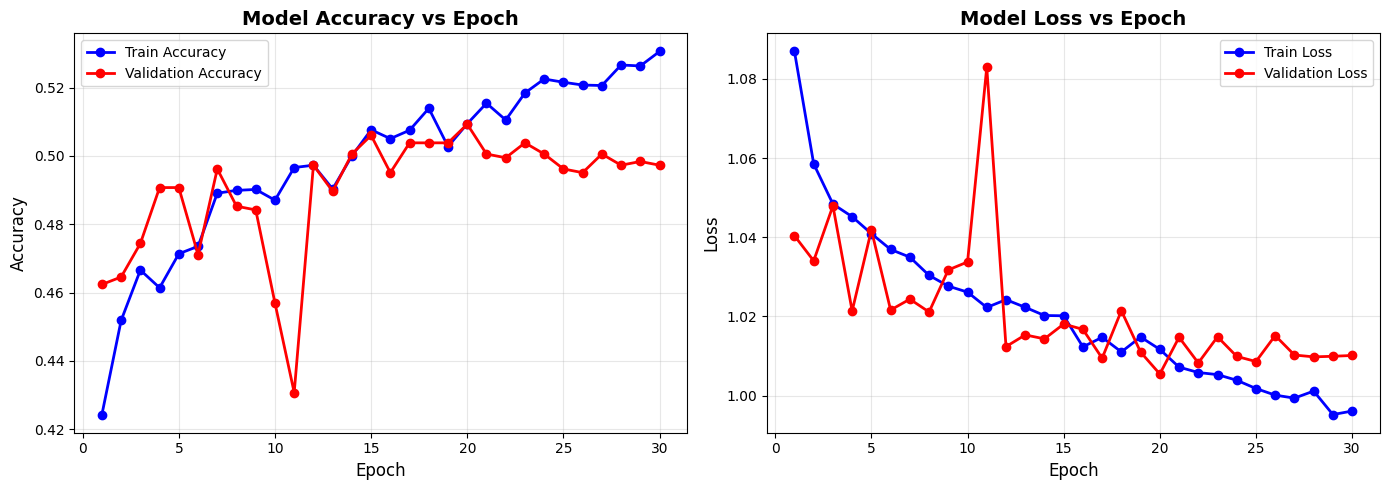


TRAINING SUMMARY
Best Validation Accuracy: 0.5093
Final Train Accuracy: 0.5306
Final Train Loss: 0.9961
Final Val Loss: 1.0101


In [79]:
# CELL 22: Plotting training curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(range(1, len(history['train_acc']) + 1), history['train_acc'], 'b-o', label='Train Accuracy', linewidth=2, markersize=6)
axes[0].plot(range(1, len(history['val_acc']) + 1), history['val_acc'], 'r-o', label='Validation Accuracy', linewidth=2, markersize=6)
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Accuracy', fontsize=12)
axes[0].set_title('Model Accuracy vs Epoch', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

axes[1].plot(range(1, len(history['train_loss']) + 1), history['train_loss'], 'b-o', label='Train Loss', linewidth=2, markersize=6)
axes[1].plot(range(1, len(history['val_loss']) + 1), history['val_loss'], 'r-o', label='Validation Loss', linewidth=2, markersize=6)
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Loss', fontsize=12)
axes[1].set_title('Model Loss vs Epoch', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/content/roberta_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n" + "="*50)
print("TRAINING SUMMARY")
print("="*50)
print(f"Best Validation Accuracy: {best_val_acc:.4f}")
if history['train_acc']:
    print(f"Final Train Accuracy: {history['train_acc'][-1]:.4f}")
    print(f"Final Train Loss: {history['train_loss'][-1]:.4f}")
    print(f"Final Val Loss: {history['val_loss'][-1]:.4f}")

Loading best model...



TEST SET RESULTS
FINAL ACCURACY: 0.5551
              precision    recall  f1-score   support

     liberal       0.64      0.52      0.57       306
      center       0.45      0.47      0.46       306
conservative       0.58      0.68      0.63       305

    accuracy                           0.56       917
   macro avg       0.56      0.56      0.55       917
weighted avg       0.56      0.56      0.55       917


Test prediction distribution:
          liberal: predicted 245 times
           center: predicted 315 times
     conservative: predicted 357 times


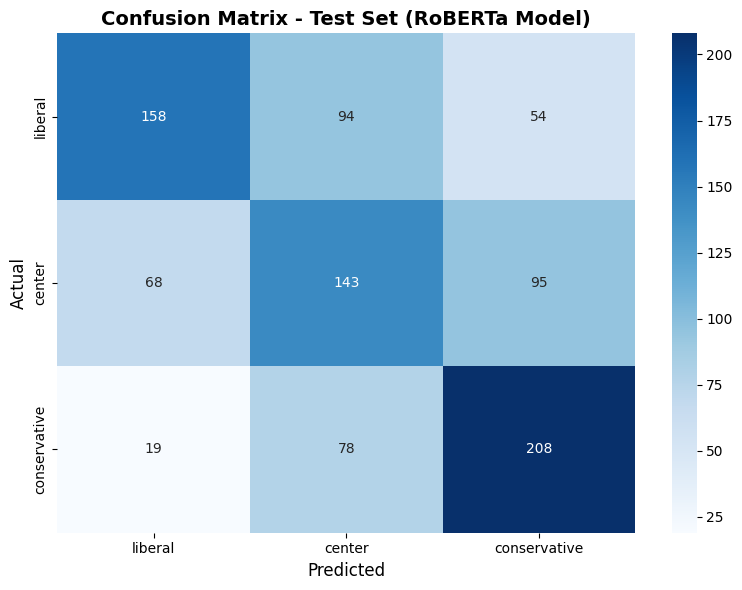

In [77]:
# CELL 23: Test set evaluation
print('Loading best model...')
model.load_state_dict(torch.load(CONFIG['SAVE_MODEL_PATH']))
model.eval()

all_preds, all_true = [], []
with torch.no_grad():
    for batch in test_loader:
        batch = {k: v.to(device) for k, v in batch.items()}
        _, predicted = torch.max(model(batch), dim=1)
        all_preds.extend(predicted.cpu().numpy())
        all_true.extend(batch['label'].cpu().numpy())

accuracy = accuracy_score(all_true, all_preds)
report = classification_report(
    all_true, all_preds, target_names=CONFIG['LABEL_NAMES'], zero_division=0
)

print(f"\n{'='*50}")
print(f'TEST SET RESULTS')
print(f"{'='*50}")
print(f'FINAL ACCURACY: {accuracy:.4f}')
print(f"{'='*50}")
print(report)

print('\nTest prediction distribution:')
final_pred_dist = Counter(all_preds)
for idx, name in enumerate(LABEL_NAMES):
    print(f'  {name:>15s}: predicted {final_pred_dist.get(idx, 0)} times')

cm = confusion_matrix(all_true, all_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=LABEL_NAMES, yticklabels=LABEL_NAMES)
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('Actual', fontsize=12)
plt.title('Confusion Matrix - Test Set (RoBERTa Model)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/roberta_confusion_matrix_test.png', dpi=150, bbox_inches='tight')
plt.show()